In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor

%matplotlib inline

pd.set_option('display.max_columns', None)

In [5]:
spotify = pd.read_csv("spotify_cleaned.csv")
spotify

,Position,Artist Name,Song Name,Days Since Released,Top 10 (xTimes),Peak Position,Peak Position (xTimes),Peak Streams,Total Streams
0,1,Post Malone,Sunflower SpiderMan: Into the SpiderVerse,1506,302,1,(x29),2118242,883369738
1,2,Juice WRLD,Lucid Dreams,1673,178,1,(x20),2127668,864832399
2,3,Lil Uzi Vert,XO TOUR Llif3,1853,212,1,(x4),1660502,781153024
3,4,J. Cole,No Role Modelz,2547,6,7,0,659366,734857487
4,5,Post Malone,rockstar,1223,186,1,(x124),2905678,718865961
...,...,...,...,...,...,...,...,...,...
11079,11080,The Band Perry,If I Die Young,1,0,184,0,51321,51321
11080,11081,Justin Timberlake,Not a Bad Thing,1,0,196,0,49512,49512
11081,11082,Mike WiLL Made,It 23,1,0,167,0,46547,46547
11082,11083,The Vamps,Somebody To You,1,0,200,0,44962,44962


In [6]:
artists = spotify["Artist Name"]
peak_streams = spotify["Peak Streams"]

In [7]:
artist_dum = pd.get_dummies(artists, columns=["Artist Name"])
artist_dum

$NOT   $ilkMoney   $uicideboy$   *NSYNC   100 gecs   2 Chainz   \
0      False       False         False    False      False      False   
1      False       False         False    False      False      False   
2      False       False         False    False      False      False   
3      False       False         False    False      False      False   
4      False       False         False    False      False      False   
...      ...         ...           ...      ...        ...        ...   
11079  False       False         False    False      False      False   
11080  False       False         False    False      False      False   
11081  False       False         False    False      False      False   
11082  False       False         False    False      False      False   
11083  False       False         False    False      False      False   

       21 Savage   22 Savage   220 KID   24kGoldn   2Pac   3 Doors Down   \
0           False       False     False      False  False          False   
1           False       False     False      False  False          False   
2           False       False     False      False  False          False   
3           False       False     False      False  False          False   
4           False       False     False      False  False          False   
...           ...         ...       ...        ...    ...            ...   
11079       False       False     False      False  False          False   
11080       False       False     False      False  False          False   
11081       False       False     False      False  False          False   
11082       False       False     False      False  False          False   
11083       False       False     False      False  False          False   

       347aidan   4*TOWN (From Disney and Pixar’s Turning Red)   42 Dugg   \
0          False                                          False     False   
1          False                                          False     False   
2          False                                          False     False   
3          False                                          False     False   
4          False                                          False     False   
...          ...                                            ...       ...   
11079      False                                          False     False   
11080      False                                          False     False   
11081      False                                          False     False   
11082      False                                          False     False   
11083      False                                          False     False   

       5 Seconds of Summer   50 Cent   6LACK   6ix9ine      88  88rising   \
0                     False     False   False     False  False      False   
1                     False     False   False     False  False      False   
2                     False     False   False     False  False      False   
3                     False     False   False     False  False      False   
4                     False     False   False     False  False      False   
...                     ...       ...     ...       ...    ...        ...   
11079                 False     False   False     False  False      False   
11080                 False     False   False     False  False      False   
11081                 False     False   False     False  False      False   
11082                 False     False   False     False  False      False   
11083                 False     False   False     False  False      False   

           A  A Boogie Wit da Hoodie   A Great Big World   A R I Z O N A   \
0      False                    False               False           False   
1      False                    False               False           False   
2      False                    False               False           False   
3      False                    False               False  

In [12]:
artist_peak_streams = pd.concat([artist_dum, peak_streams], axis=1)
artist_peak_streams

$NOT   $ilkMoney   $uicideboy$   *NSYNC   100 gecs   2 Chainz   \
0      False       False         False    False      False      False   
1      False       False         False    False      False      False   
2      False       False         False    False      False      False   
3      False       False         False    False      False      False   
4      False       False         False    False      False      False   
...      ...         ...           ...      ...        ...        ...   
11079  False       False         False    False      False      False   
11080  False       False         False    False      False      False   
11081  False       False         False    False      False      False   
11082  False       False         False    False      False      False   
11083  False       False         False    False      False      False   

       21 Savage   22 Savage   220 KID   24kGoldn   2Pac   3 Doors Down   \
0           False       False     False      False  False          False   
1           False       False     False      False  False          False   
2           False       False     False      False  False          False   
3           False       False     False      False  False          False   
4           False       False     False      False  False          False   
...           ...         ...       ...        ...    ...            ...   
11079       False       False     False      False  False          False   
11080       False       False     False      False  False          False   
11081       False       False     False      False  False          False   
11082       False       False     False      False  False          False   
11083       False       False     False      False  False          False   

       347aidan   4*TOWN (From Disney and Pixar’s Turning Red)   42 Dugg   \
0          False                                          False     False   
1          False                                          False     False   
2          False                                          False     False   
3          False                                          False     False   
4          False                                          False     False   
...          ...                                            ...       ...   
11079      False                                          False     False   
11080      False                                          False     False   
11081      False                                          False     False   
11082      False                                          False     False   
11083      False                                          False     False   

       5 Seconds of Summer   50 Cent   6LACK   6ix9ine      88  88rising   \
0                     False     False   False     False  False      False   
1                     False     False   False     False  False      False   
2                     False     False   False     False  False      False   
3                     False     False   False     False  False      False   
4                     False     False   False     False  False      False   
...                     ...       ...     ...       ...    ...        ...   
11079                 False     False   False     False  False      False   
11080                 False     False   False     False  False      False   
11081                 False     False   False     False  False      False   
11082                 False     False   False     False  False      False   
11083                 False     False   False     False  False      False   

           A  A Boogie Wit da Hoodie   A Great Big World   A R I Z O N A   \
0      False                    False               False           False   
1      False                    False               False           False   
2      False                    False               False           False   
3      False                    False               False  

In [13]:
x = artist_peak_streams
y = spotify["Total Streams"]

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size= .2, random_state=42)

In [15]:
knn = KNeighborsRegressor(n_neighbors = 3)
knn.fit(x_train, y_train)

KNeighborsRegressor(n_neighbors=3)

In [16]:
y_test_pred = knn.predict(x_test)
y_train_pred = knn.predict(x_train)

In [17]:
print("The MSE of this model's training data is ", mean_squared_error(y_train, y_train_pred))
print("The MSE of this model's testing data is ", mean_squared_error(y_test, y_test_pred))

# This model is overfitting because the testing data's MSE is greater than the one for the training data

The MSE of this model's training data is  1399468548695456.0
The MSE of this model's testing data is  3110114771858796.0


In [18]:
peak_pos = spotify["Peak Position"]
position_dum = pd.get_dummies(peak_pos, columns=["Artist Name"])
position_dum

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200
0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fals

In [19]:
streams_pos = pd.concat([position_dum, peak_streams], axis=1)

In [23]:
x = streams_pos
x.columns = x.columns.astype(str)

In [24]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size= .2, random_state=42)

MSE for k =  1 done!
MSE for k =  2 done!
MSE for k =  3 done!
MSE for k =  4 done!
MSE for k =  5 done!
MSE for k =  6 done!
MSE for k =  7 done!
MSE for k =  8 done!
MSE for k =  9 done!
MSE for k =  10 done!
MSE for k =  11 done!
MSE for k =  12 done!
MSE for k =  13 done!
MSE for k =  14 done!
MSE for k =  15 done!
MSE for k =  16 done!
MSE for k =  17 done!
MSE for k =  18 done!
MSE for k =  19 done!
MSE for k =  20 done!
MSE for k =  21 done!
MSE for k =  22 done!
MSE for k =  23 done!
MSE for k =  24 done!


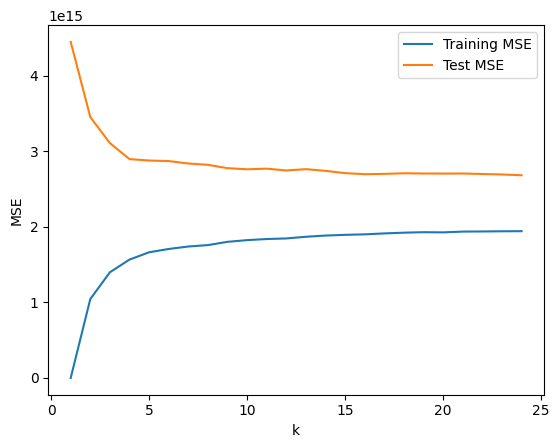

In [32]:
k_vals = range(1, 25)
mse_train_list = []
mse_test_list = []

for k in k_vals:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(x_train, y_train)

    pred_train = knn.predict(x_train)
    pred_test = knn.predict(x_test)

    mse_train_list.append(mean_squared_error(y_train, pred_train))
    mse_test_list.append(mean_squared_error(y_test, pred_test))
    print("MSE for k = ", k, "done!")

plt.plot(k_vals, mse_train_list, label="Training MSE")
plt.plot(k_vals, mse_test_list, label="Test MSE")
plt.xlabel("k")
plt.ylabel("MSE")
plt.legend()
plt.show()

In [33]:
knn24 = KNeighborsRegressor(n_neighbors=24)
knn24.fit(x_train, y_train)

KNeighborsRegressor(n_neighbors=24)

In [34]:
y24_test_pred = knn24.predict(x_test)
y24_train_pred = knn24.predict(x_train)

In [35]:
print("The MSE of this model's training data is ", mean_squared_error(y_train, y24_train_pred))
print("The MSE of this model's testing data is ", mean_squared_error(y_test, y24_test_pred))

# This model is not overfitting

The MSE of this model's training data is  1943641289517114.5
The MSE of this model's testing data is  2684407903966183.5
